In [1]:
import kagglehub
path = kagglehub.dataset_download("vikasukani/parkinsons-disease-data-set")

100%|██████████| 15.6k/15.6k [00:00<00:00, 18.9MB/s]

Extracting files...


In [44]:
pip install numpy pandas scikit-learn matplotlib


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("/content/parkinsons.data")

X = df.drop(["name", "status"], axis=1)
y = df["status"]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions (important for quantum later)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(kernel="rbf")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Classical SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Classical SVM Accuracy: 0.8717948717948718
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.89      0.97      0.93        32

    accuracy                           0.87        39
   macro avg       0.82      0.70      0.74        39
weighted avg       0.86      0.87      0.86        39



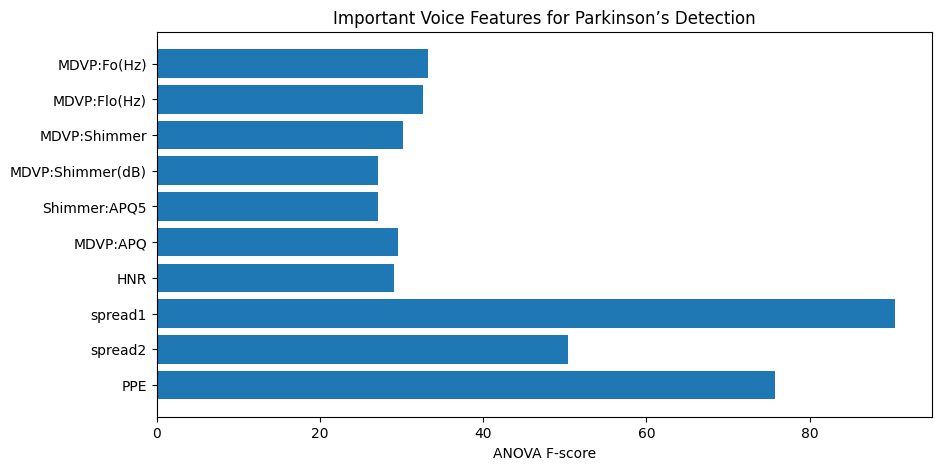

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
# Example: Parkinson's dataset
# 'status' → label (1 = Parkinson’s, 0 = Healthy)

X = df.drop(columns=['status', 'name']) # Drop 'name' column as it contains strings
y = df['status']

feature_names = X.columns
selector = SelectKBest(score_func=f_classif, k=10)  # select top 10 features
selector.fit(X, y)

feature_scores = selector.scores_
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]
selected_scores = feature_scores[selected_mask]
plt.figure(figsize=(10, 5))
plt.barh(selected_features, selected_scores)
plt.xlabel("ANOVA F-score")
plt.title("Important Voice Features for Parkinson’s Detection")
plt.gca().invert_yaxis()
plt.show()

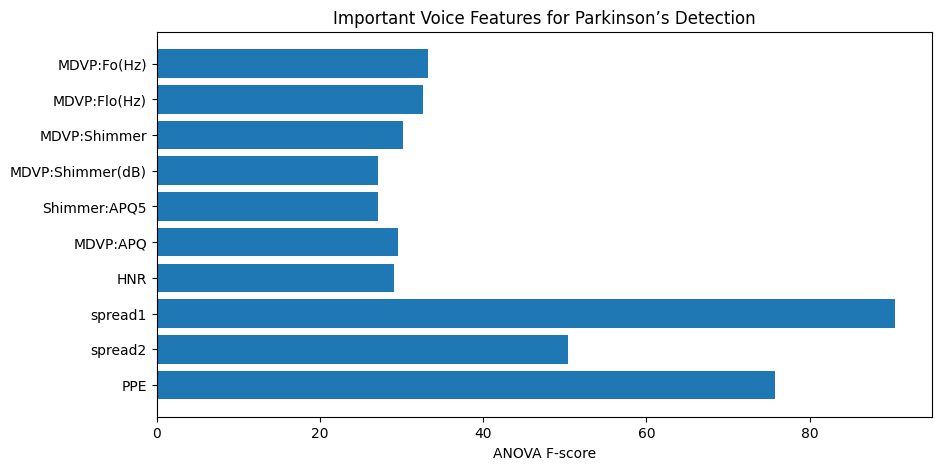

In [9]:
import matplotlib.pyplot as plt
import numpy as np

selected_scores = feature_scores[selected_mask]

plt.figure(figsize=(10, 5))
plt.barh(selected_features, selected_scores)
plt.xlabel("ANOVA F-score")
plt.title("Important Voice Features for Parkinson’s Detection")
plt.gca().invert_yaxis()
plt.show()


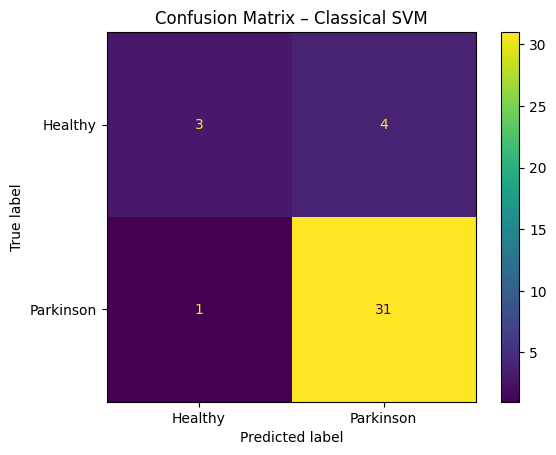

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    display_labels=["Healthy", "Parkinson"]
)

plt.title("Confusion Matrix – Classical SVM")
plt.show()

In [12]:
!pip install pennylane


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 40.5 MB/s eta 0:00:00


In [13]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.state()


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [14]:
def quantum_kernel(x1, x2):
    state1 = quantum_feature_map(x1)
    state2 = quantum_feature_map(x2)
    return np.abs(np.dot(np.conj(state1), state2))**2


In [17]:
def kernel_matrix(X1, X2):
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)


In [18]:
quantum_svm = SVC(kernel="precomputed")
quantum_svm.fit(K_train, y_train)

y_pred_q = quantum_svm.predict(K_test)

print("Quantum SVM Accuracy:", accuracy_score(y_test, y_pred_q))
print(classification_report(y_test, y_pred_q))


Quantum SVM Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.91      1.00      0.96        32

    accuracy                           0.92        39
   macro avg       0.96      0.79      0.84        39
weighted avg       0.93      0.92      0.91        39



In [19]:
def entangle():
    for i in range(n_qubits):
        qml.CNOT(wires=[i, (i+1) % n_qubits])


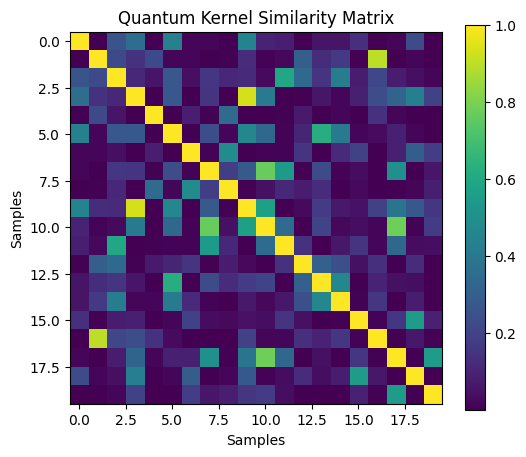

In [20]:
import matplotlib.pyplot as plt

def kernel_matrix(X1, X2):
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])

K = kernel_matrix(X_train[:20], X_train[:20])

plt.figure(figsize=(6, 5))
plt.imshow(K, cmap="viridis")
plt.colorbar()
plt.title("Quantum Kernel Similarity Matrix")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()


In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

quantum_svm = SVC(kernel="precomputed")
quantum_svm.fit(K_train, y_train)

y_pred_q = quantum_svm.predict(K_test)

print("Enhanced Quantum Accuracy:", accuracy_score(y_test, y_pred_q))


Enhanced Quantum Accuracy: 0.9230769230769231


In [22]:
import pennylane as qml
import numpy as np

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def enhanced_feature_map(x, params):
    for layer in range(n_layers):
        # Data encoding
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)

        # Trainable rotations
        for i in range(n_qubits):
            qml.RZ(params[layer, i], wires=i)

        # Entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

    return qml.state()


In [29]:
#Visualize the Quantum Circuit
import pennylane as qml
import numpy as np

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def enhanced_feature_map(x, params):
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)

        for i in range(n_qubits):
            qml.RZ(params[layer, i], wires=i)

        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

    return qml.state()

# Sample input
x = np.random.rand(n_qubits)
params = np.random.rand(n_layers, n_qubits)

# Draw circuit
drawer = qml.draw(enhanced_feature_map)
print(drawer(x, params))


0: ──RY(0.59)──RZ(0.64)─╭●──RY(0.59)──RZ(0.02)───────────╭●──────────────┤  State
1: ──RY(0.46)──RZ(0.11)─╰X─╭●─────────RY(0.46)──RZ(0.30)─╰X────────╭●────┤  State
2: ──RY(0.01)──RZ(0.08)────╰X────────╭●─────────RY(0.01)──RZ(0.79)─╰X─╭●─┤  State
3: ──RY(0.97)──RZ(0.29)──────────────╰X─────────RY(0.97)──RZ(0.82)────╰X─┤  State


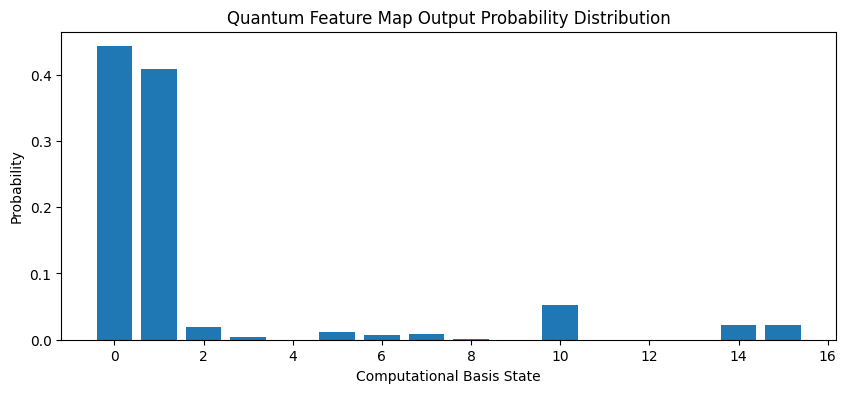

In [24]:
#Visualize Quantum State Probabilities
state = enhanced_feature_map(x, params)

# Probability distribution
probs = np.abs(state)**2

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(range(len(probs)), probs)
plt.xlabel("Computational Basis State")
plt.ylabel("Probability")
plt.title("Quantum Feature Map Output Probability Distribution")
plt.show()


In [25]:
#Modify QNode
@qml.qnode(dev)
def bloch_feature_map(x, params):
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
            qml.RZ(params[layer, i], wires=i)

        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)], \
           [qml.expval(qml.PauliY(i)) for i in range(n_qubits)], \
           [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


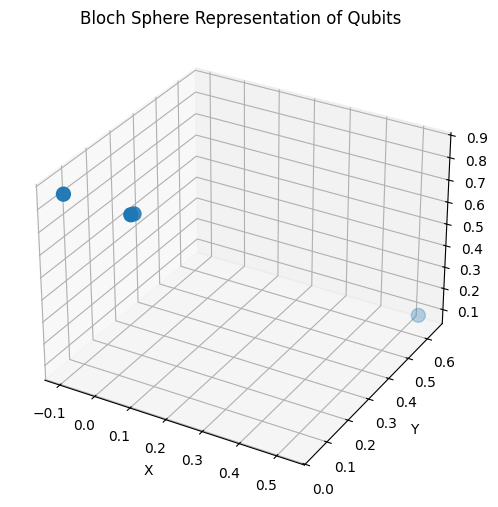

In [26]:
#Plot Bloch Vectors
X, Y, Z = bloch_feature_map(x, params)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X, Y, Z, s=100)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Bloch Sphere Representation of Qubits")
plt.show()


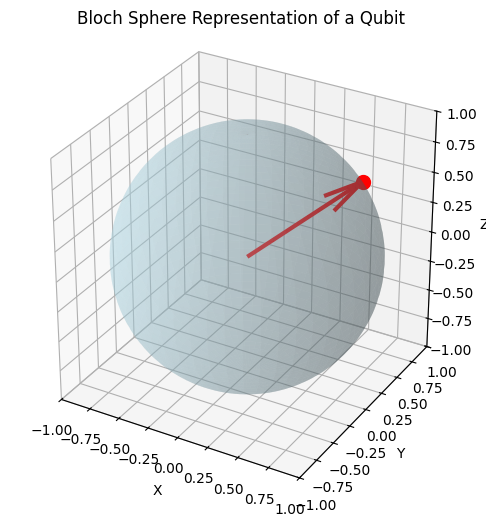

In [45]:
#create bloch sphere using pennyslyvia
import numpy as np
import matplotlib.pyplot as plt

# Create sphere surface
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Sphere surface
ax.plot_surface(x, y, z, color='lightblue', alpha=0.3)

# Example qubit state (theta, phi)
theta = np.pi / 3
phi = np.pi / 4

# Bloch vector
bx = np.sin(theta) * np.cos(phi)
by = np.sin(theta) * np.sin(phi)
bz = np.cos(theta)

# Plot state vector
ax.quiver(0, 0, 0, bx, by, bz, color='red', linewidth=3)
ax.scatter(bx, by, bz, color='red', s=100)

# Labels and limits
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Bloch Sphere Representation of a Qubit")

ax.set_box_aspect([1,1,1])  # Equal aspect ratio
plt.show()


In [46]:
!pip install qiskit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.1 MB/s eta 0:00:00


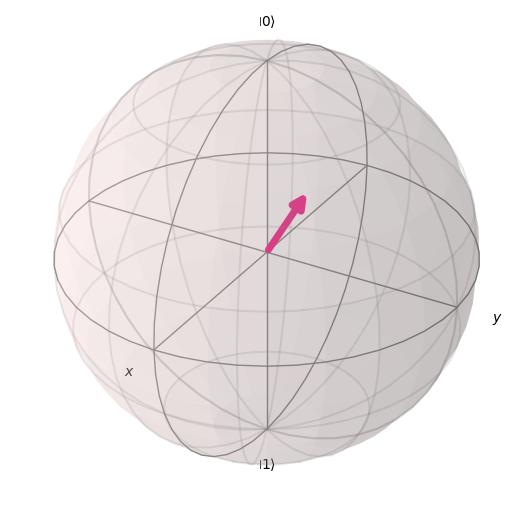

In [49]:
#bloch sphere visualization using Qiskit
from qiskit.visualization import plot_bloch_vector
from IPython.display import display

bloch_vector = [0.5, 0.5, 0.707]
fig = plot_bloch_vector(bloch_vector)

display(fig)



In [27]:
#Kernel Visualization
def quantum_kernel(x1, x2, params):
    state1 = enhanced_feature_map(x1, params)
    state2 = enhanced_feature_map(x2, params)
    return np.abs(np.dot(np.conj(state1), state2))**2


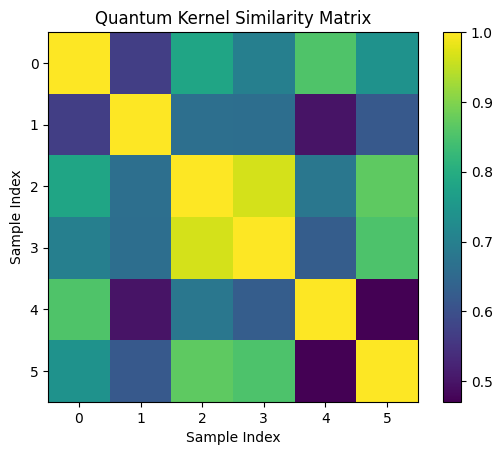

In [28]:
#Kernel Matrix
X_data = np.random.rand(6, n_qubits)

kernel_matrix = np.zeros((len(X_data), len(X_data)))

for i in range(len(X_data)):
    for j in range(len(X_data)):
        kernel_matrix[i, j] = quantum_kernel(X_data[i], X_data[j], params)

plt.imshow(kernel_matrix, cmap="viridis")
plt.colorbar()
plt.title("Quantum Kernel Similarity Matrix")
plt.xlabel("Sample Index")
plt.ylabel("Sample Index")
plt.show()


In [31]:
#Noisy device setup
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

n_qubits = 4
n_layers = 2

# NISQ device (mixed state)
dev_noisy = qml.device(
    "default.mixed",
    wires=n_qubits,
    shots=1000  # finite shots = measurement noise
)


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [32]:
#Enhanced Feature Map with Noise Injection, We add noise after every layer.
# Noisy Quantum Feature Map
@qml.qnode(dev_noisy)
def noisy_feature_map(x, params):
    for layer in range(n_layers):

        # Data encoding
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)

        # Trainable rotations
        for i in range(n_qubits):
            qml.RZ(params[layer, i], wires=i)

        # Entanglement
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

        # --- Noise Injection (NISQ) ---
        for i in range(n_qubits):
            qml.DepolarizingChannel(0.01, wires=i)   # gate noise
            qml.PhaseDamping(0.02, wires=i)          # dephasing

    # Measurement noise via finite shots
    return qml.probs(wires=range(n_qubits))


In [33]:
#run the noisy circuit
x = np.random.rand(n_qubits)
params = np.random.rand(n_layers, n_qubits)

noisy_probs = noisy_feature_map(x, params)


In [34]:
#ideal
dev_ideal = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_ideal)
def ideal_feature_map(x, params):
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
            qml.RZ(params[layer, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

    return qml.probs(wires=range(n_qubits))

ideal_probs = ideal_feature_map(x, params)


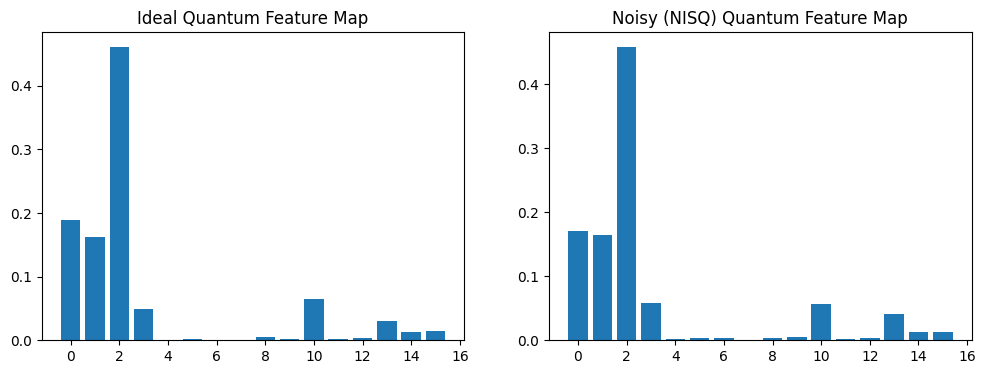

In [35]:
#visualization
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(range(len(ideal_probs)), ideal_probs)
plt.title("Ideal Quantum Feature Map")

plt.subplot(1,2,2)
plt.bar(range(len(noisy_probs)), noisy_probs)
plt.title("Noisy (NISQ) Quantum Feature Map")

plt.show()


In [36]:
#Add Readout (Measurement) Noise
@qml.qnode(dev_noisy)
def readout_noisy_map(x, params):
    for layer in range(n_layers):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
            qml.RZ(params[layer, i], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])

    # Measurement noise via classical bit flip
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


In [37]:
#comparision of other models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogReg": LogisticRegression(max_iter=200),
    "RF": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(kernel="rbf")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, accuracy_score(y_test, preds))



LogReg 0.8974358974358975
RF 0.8717948717948718
SVM 0.8717948717948718


In [41]:
#mean classical accuracy
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5)
classical_scores = cross_val_score(svm, X_pca, y, cv=cv)
print("Mean Classical Accuracy:", classical_scores.mean())

Mean Classical Accuracy: 0.8


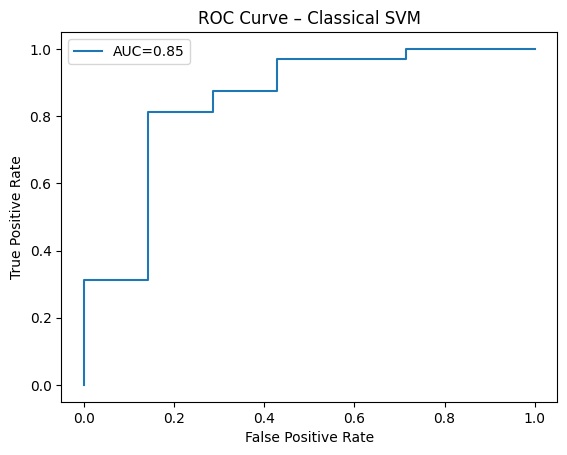

In [40]:
#Add ROC Curve
from sklearn.metrics import roc_curve, auc

probs = svm.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Classical SVM")
plt.show()


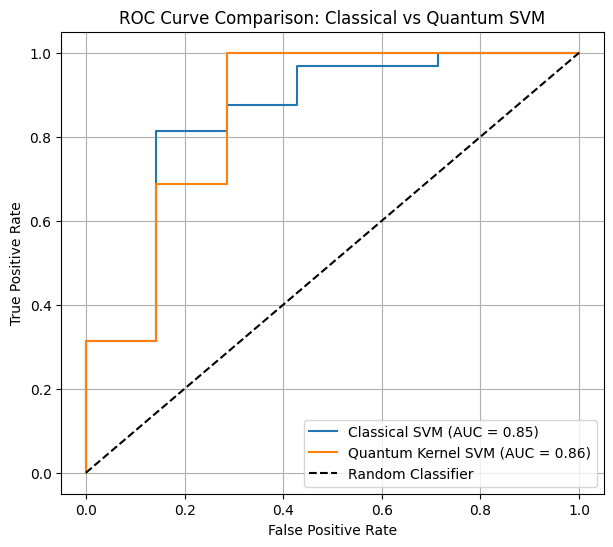

In [43]:
#FINAL CODE: ROC–AUC (Classical vs Quantum)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# -------- Classical SVM ROC --------
classical_scores = svm.decision_function(X_test)
fpr_c, tpr_c, _ = roc_curve(y_test, classical_scores)
auc_c = auc(fpr_c, tpr_c)

# -------- Quantum SVM ROC --------
quantum_scores = quantum_svm.decision_function(K_test)
fpr_q, tpr_q, _ = roc_curve(y_test, quantum_scores)
auc_q = auc(fpr_q, tpr_q)

# -------- Plot Both --------
plt.figure(figsize=(7, 6))
plt.plot(fpr_c, tpr_c, label=f"Classical SVM (AUC = {auc_c:.2f})")
plt.plot(fpr_q, tpr_q, label=f"Quantum Kernel SVM (AUC = {auc_q:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Classical vs Quantum SVM")
plt.legend()
plt.grid(True)
plt.show()
